Time series data refers to data that is collected,recorded or observed over time in a sequential order.

Characteristics:
- Chronological Order : Observations are observed in time(D,W,N,Y,s,m,h)
- Sequential Dependency : The order of the data matters because previous values can influenceor predict the future values.
- Temporal components : Trend,Seasonality,Cycle,noise

Time series Analysis:

- statistical technique: meaningful insights about pattern and trends
- forecasting

Time Series Decomposition

- Trend:long term direction
- Seasonality : repeating pattern at fixed interval
- Noise

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Using airline passengers dataset (monthly totals)
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month' )
df

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


<Axes: xlabel='Month'>

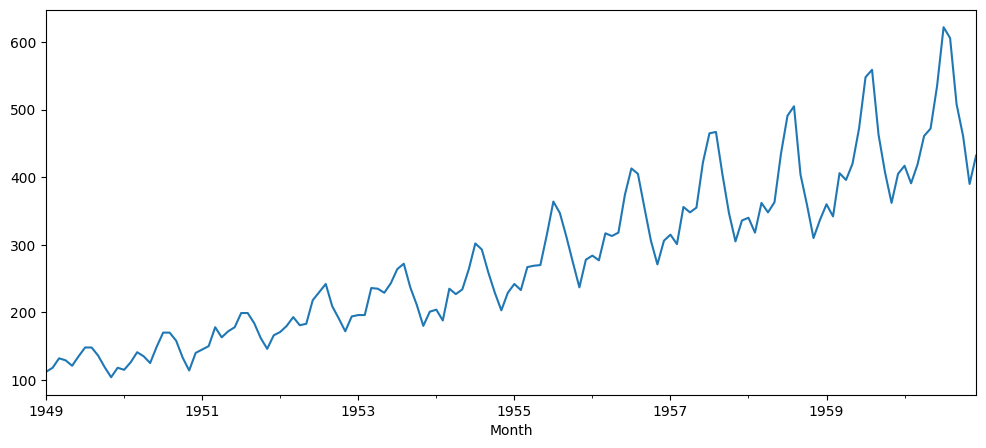

In [14]:
df['Passengers'].plot(figsize=(12,5))

- Additive: $Y_t = T_t + S_t + R_t$
- Multiplicative: $Y_t = T_t \times S_t \times R_t$

# 📊 Time Series Decomposition

## 🔹 Observed Value $(Y_t)$
- The **actual recorded data** at time *t*  
- It is a combination of all components  

**Example:** Daily sales = 500 units  

---

## 🔹 Trend Component $(T_t)$
- Shows the **overall direction** of data over a long period  
- Can be **upward 📈, downward 📉, or stable ➖**  

**Example:**  
- Sales increasing every year due to business growth  

---

## 🔹 Seasonal Component $(S_t)$
- Represents **repeating patterns** over fixed time intervals  
- Occurs due to **season, festivals, habits, or cycles**  

**Example:**  
- Ice cream sales increase in summer 🍦  
- Online shopping spikes during Diwali 🛍️  

---

## 🔹 Residual Component $(R_t)$
- Captures **random, unpredictable variations**  
- Also called **noise or irregular component**  

**Example:**  
- Sudden drop in sales due to lockdown  

---

# 📌 Mathematical Models

## ➤ Additive Model
$$
Y_t = T_t + S_t + R_t
$$

- Used when **seasonal variation is constant**
- Effect of season does **not depend on trend**

### 📊 Example:
If:
- $T_t = 100$
- $S_t = 20$
- $R_t = 5$

Then:
$$
Y_t = 100 + 20 + 5 = 125
$$

---

## ➤ Multiplicative Model
$$
Y_t = T_t \times S_t \times R_t
$$

- Used when **seasonal variation changes with trend**
- Effect of season is **percentage-based**

### 📊 Example:
If:
- $T_t = 100$
- $S_t = 1.2$
- $R_t = 1.05$

Then:
$$
Y_t = 100 \times 1.2 \times 1.05 = 126
$$

  

In [15]:
import yfinance as yf
ticker_symbol = 'RELIANCE.NS'
stock_data = yf.download(ticker_symbol, start='2026-01-01', end='2026-04-17', interval='1d')
stock_data.columns = stock_data.columns.droplevel("Ticker")
stock_data

/tmp/ipykernel_4871/4250500385.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker_symbol, start='2026-01-01', end='2026-04-17', interval='1d')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-01-01,1575.599976,1592.500000,1571.099976,1573.699951,6408128
2026-01-02,1592.300049,1594.599976,1578.199951,1580.000000,6602230
2026-01-05,1578.099976,1611.800049,1575.300049,1593.000000,8704973
2026-01-06,1507.599976,1569.000000,1496.300049,1569.000000,27417125
2026-01-07,1504.199951,1520.000000,1498.000000,1510.000000,11199340
...,...,...,...,...,...
2026-04-09,1330.000000,1350.000000,1326.300049,1346.000000,20725390
2026-04-10,1350.199951,1352.300049,1331.500000,1337.000000,19364461
2026-04-13,1315.099976,1327.599976,1310.000000,1321.199951,28753269


In [16]:
type(stock_data.index)

pandas.core.indexes.datetimes.DatetimeIndex

<Axes: xlabel='Date'>

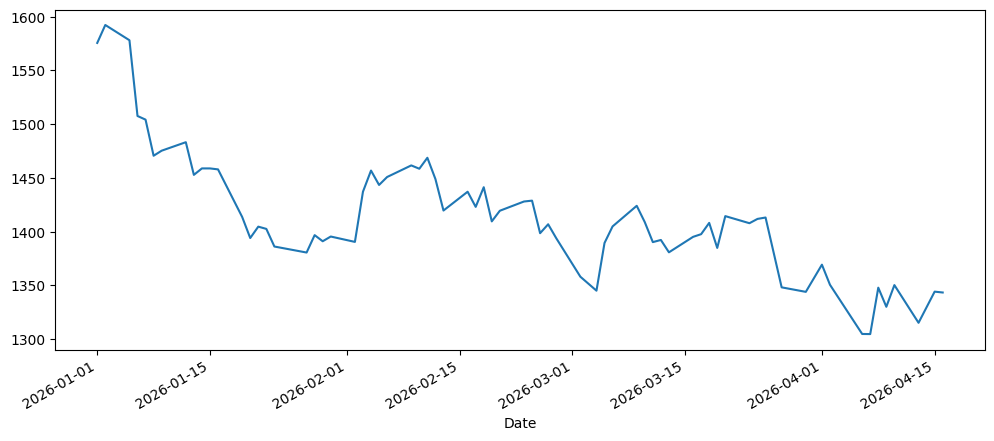

In [17]:
stock_data["Close"].plot(figsize = (12,5))

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose
sd = seasonal_decompose(df["Passengers"], model="multiplicative", period =10)

In [19]:
trend = sd.trend
seasonal = sd.seasonal
residual = sd.resid

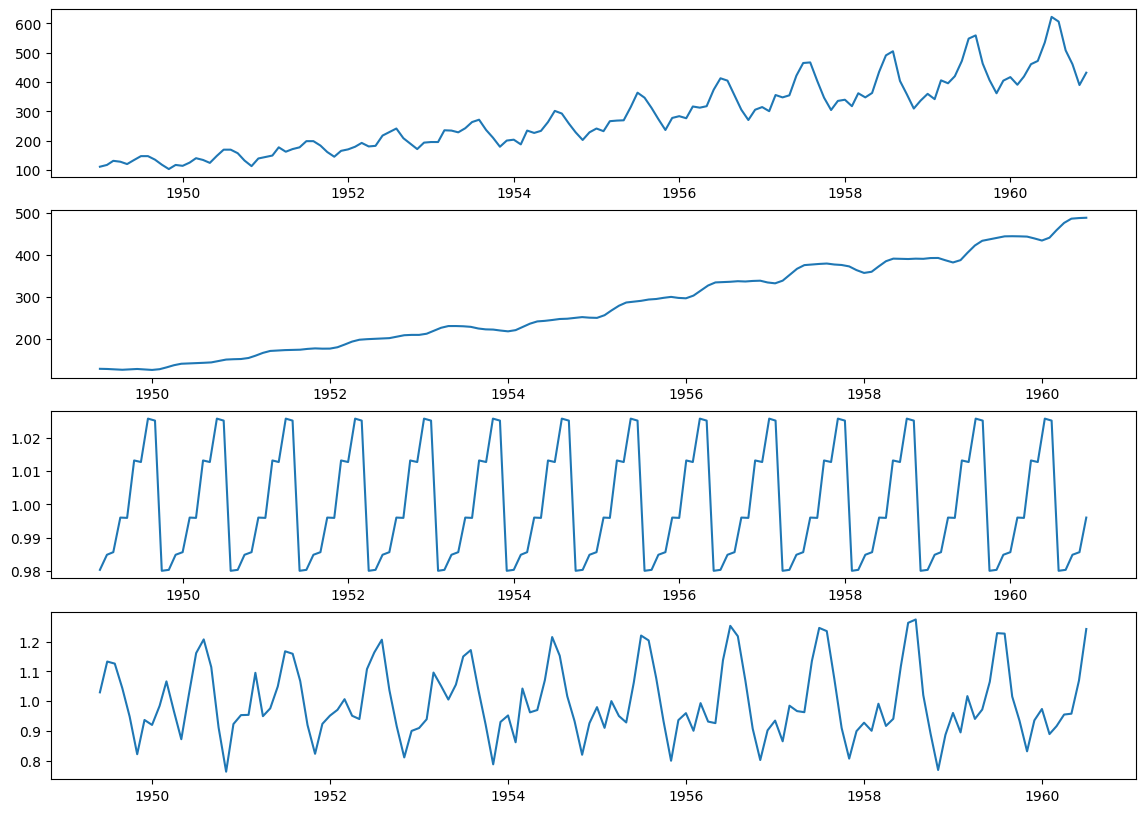

In [20]:
plt.figure(figsize=(14,10))
plt.subplot(411)
plt.plot(df["Passengers"])
plt.subplot(412)
plt.plot(trend)
plt.subplot(413)
plt.plot(seasonal)
plt.subplot(414)
plt.plot(residual)
plt.show()

In [21]:
sd = seasonal_decompose(stock_data["Close"], model="additive", period =10)

In [23]:
trend = sd.trend
seasonal = sd.seasonal
residuals = sd.resid

In [24]:
import matplotlib.pyplot as plt

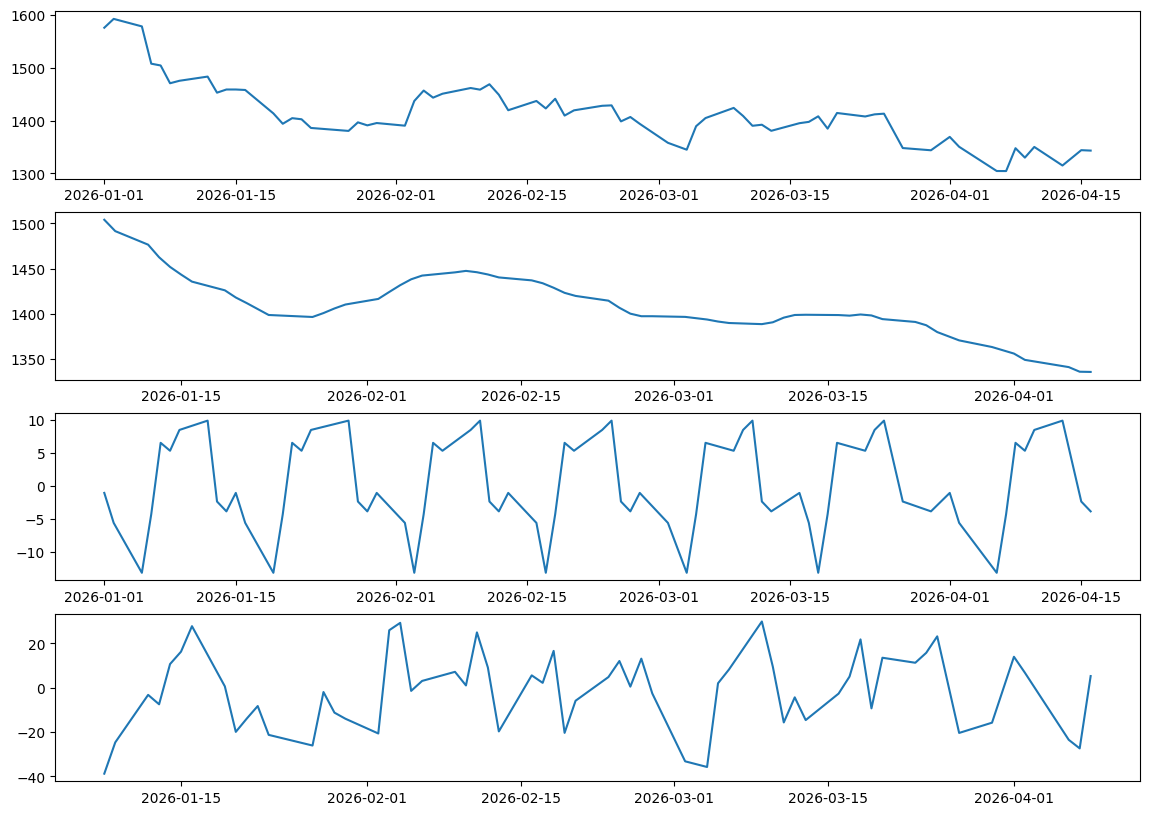

In [25]:
plt.figure(figsize=(14,10))
plt.subplot(411)
plt.plot(stock_data["Close"])
plt.subplot(412)
plt.plot(trend)
plt.subplot(413)
plt.plot(seasonal)
plt.subplot(414)
plt.plot(residuals)
plt.show()

- Assumes fixed seasonal patterns
- Easily influenced by the outliers
- Handle both additive and multiplicative models
- Preferred for multiplicative models

# 📊 Additive vs Multiplicative Time Series Model

## 🔍 Key Differences

| Feature | Additive Model | Multiplicative Model |
|--------|---------------|----------------------|
| Formula | $Y_t = T_t + S_t + R_t$ | $Y_t = T_t \times S_t \times R_t$ |
| Nature of Change | **Absolute (fixed)** | **Relative (percentage)** |
| Seasonal Variation | Constant over time | Changes with trend |
| Data Behavior | Stable fluctuations | Increasing/decreasing fluctuations |
| Interpretation | Same seasonal effect each period | Seasonal effect proportional to level |

---

## 📌 When to Use Additive Model
- When **seasonal fluctuations are constant**
- When data shows **uniform variation over time**
- When trend does **not affect seasonal pattern**

### ✅ Example:
- Temperature data 🌡️  
- Fixed increase in sales every year  

---

## 📌 When to Use Multiplicative Model
- When **seasonal fluctuations increase/decrease with trend**
- When data shows **percentage growth or decline**
- When trend **impacts seasonal effect**

### ✅ Example:
- Business sales growing over time 📈  
- Stock market data  

---

## ⚖️ Which One to Prefer?

- ✔️ Use **Additive Model** → if variation is **constant (linear pattern)**  
- ✔️ Use **Multiplicative Model** → if variation is **proportional (exponential pattern)**  

---

## 🧠 Quick Rule
- If **pattern size stays same → Additive**  
- If **pattern grows/shrinks → Multiplicative**

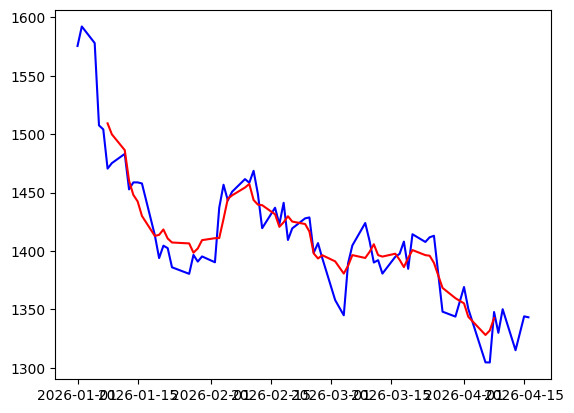

In [26]:
import matplotlib.pyplot as plt
estimated = trend + seasonal
plt.plot(stock_data["Close"], color="blue")
plt.plot(estimated, color="red")
plt.show()

In [27]:
estimated.fillna(0)

,0
Date,
2026-01-01,0.0
2026-01-02,0.0
2026-01-05,0.0
2026-01-06,0.0
2026-01-07,0.0
...,...
2026-04-09,0.0
2026-04-10,0.0
2026-04-13,0.0


In [28]:
from sklearn.metrics import mean_squared_error
mean_squared_error(stock_data["Close"], estimated.fillna(0))

299911.3744967992